In [1]:
pip install scipy pandas numpy tensorflow scikit-learn matplotlib keras-squeezenet

Note: you may need to restart the kernel to use updated packages.


# Разделение на ячейки для удобства

In [1]:
# === Глобальные параметры и утилиты (единые для всех моделей) ===
import os, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Импорты компонентов Keras для работы с изображениями, слоями и метриками
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# ----- Параметры -----
# Настройки размеров изображений и параметров обучения
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 10
NUM_CLASSES = 5
DATA_DIR    = 'open-images-dataset'  # структура данных: train/ val/ test поддиректории

# Параметры обучения со значениями по умолчанию
LR_HEAD       = 1e-4                 # скорость обучения для дообучения классификатора
LABEL_SMOOTH  = 0.05                 # коэффициент сглаживания меток для устойчивости к шуму
SAVE_DIR      = '.'                  # директория для сохранения моделей и результатов
os.makedirs(SAVE_DIR, exist_ok=True)

# ----- Утилиты -----
def make_generators_with_preprocess(preprocess_fn=None):
    """Создаёт генераторы данных для train/val/test с предобработкой.
       Если функция предобработки не задана, применяется простое масштабирование 1/255."""
    if preprocess_fn is None:
        # Базовое масштабирование пикселей к диапазону [0,1]
        tr = ImageDataGenerator(rescale=1./255)
        va = ImageDataGenerator(rescale=1./255)
        te = ImageDataGenerator(rescale=1./255)
    else:
        # Использование пользовательской функции предобработки (например, для нормализации под конкретную модель)
        tr = ImageDataGenerator(preprocessing_function=preprocess_fn)
        va = ImageDataGenerator(preprocessing_function=preprocess_fn)
        te = ImageDataGenerator(preprocessing_function=preprocess_fn)

    # Загрузка данных из директорий с автоматическим определением классов
    train_gen = tr.flow_from_directory(
        f'{DATA_DIR}/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
    )
    val_gen = va.flow_from_directory(
        f'{DATA_DIR}/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
    )
    test_gen = te.flow_from_directory(
        f'{DATA_DIR}/test', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False  # без перемешивания для валидной оценки
    )
    return train_gen, val_gen, test_gen

def create_model(base_model, num_classes=NUM_CLASSES,
                 lr=LR_HEAD, label_smooth=LABEL_SMOOTH):
    """Создаёт модель: замороженная предобученная основа + новый классификатор сверху."""
    base_model.trainable = False  # заморозка слоев предобученной модели
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # уменьшение размерности пространственных признаков
    x = Dropout(0.2)(x)              # регуляризация для предотвращения переобучения
    x = Dense(1024, activation='relu')(x)  # полносвязный слой для обучения признаков
    outputs = Dense(num_classes, activation='softmax')(x)  # выходной слой с softmax для классификации
    model = Model(inputs=base_model.input, outputs=outputs)
    # Компиляция модели со сглаживанием меток для лучшей обобщающей способности
    model.compile(optimizer=Adam(lr),
                  loss=CategoricalCrossentropy(label_smoothing=label_smooth),
                  metrics=['accuracy'])
    return model

def train_and_eval(model, train_gen, val_gen, test_gen, epochs=EPOCHS, title='Model'):
    """Обучает модель и оценивает её на тестовых данных.
       Возвращает метрики, истинные метки и предсказанные классы."""
    # Расчет количества шагов на эпоху для генераторов
    steps_per_epoch = math.ceil(train_gen.samples / BATCH_SIZE)
    val_steps       = math.ceil(val_gen.samples   / BATCH_SIZE)

    # Обучение модели
    history = model.fit(
        train_gen,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_gen,
        validation_steps=val_steps,
        epochs=epochs,
        verbose=1
    )

    # Оценка модели на тестовых данных
    y_true = test_gen.classes  # истинные метки классов
    y_pred = model.predict(test_gen, verbose=0)  # вероятности классов
    y_pred_classes = np.argmax(y_pred, axis=1)  # преобразование вероятностей в классы

    # Построение и отображение матрицы ошибок
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=test_gen.class_indices.keys(),
                yticklabels=test_gen.class_indices.keys())
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

    # Расчет дополнительных метрик качества классификации
    precision = precision_score(y_true, y_pred_classes, average='macro')
    recall    = recall_score(y_true, y_pred_classes,  average='macro')
    f1        = f1_score(y_true, y_pred_classes,      average='macro')
    print(f"{title} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    # Упаковка метрик в словарь для возврата
    metrics = dict(precision=precision, recall=recall, f1=f1)
    return metrics, y_true, y_pred_classes

Found 29493 images belonging to 5 classes.
Found 3722 images belonging to 5 classes.
Found 3718 images belonging to 5 classes.


C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 744s 802ms/step - accuracy: 0.8429 - loss: 0.6061 - val_accuracy: 0.8992 - val_loss: 0.4801
Epoch 2/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 692s 750ms/step - accuracy: 0.9066 - loss: 0.4653 - val_accuracy: 0.9033 - val_loss: 0.4637
Epoch 3/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 682s 739ms/step - accuracy: 0.9184 - loss: 0.4385 - val_accuracy: 0.9052 - val_loss: 0.4524
Epoch 4/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 686s 744ms/step - accuracy: 0.9276 - loss: 0.4157 - val_accuracy: 0.9105 - val_loss: 0.4489
Epoch 5/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 688s 746ms/step - accuracy: 0.9343 - loss: 0.4014 - val_accuracy: 0.9065 - val_loss: 0.4454
Epoch 6/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 681s 739ms/step - accuracy: 0.9381 - loss: 0.3931 - val_accuracy: 0.9087 - val_loss: 0.4408
Epoch 7/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 684s 741ms/step - accuracy: 0.9471 - loss: 0.3751 - val_accuracy: 0.9111 - val_loss: 0.4408
Epoch 8/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 688s 746ms/step - accuracy: 0.9528 -

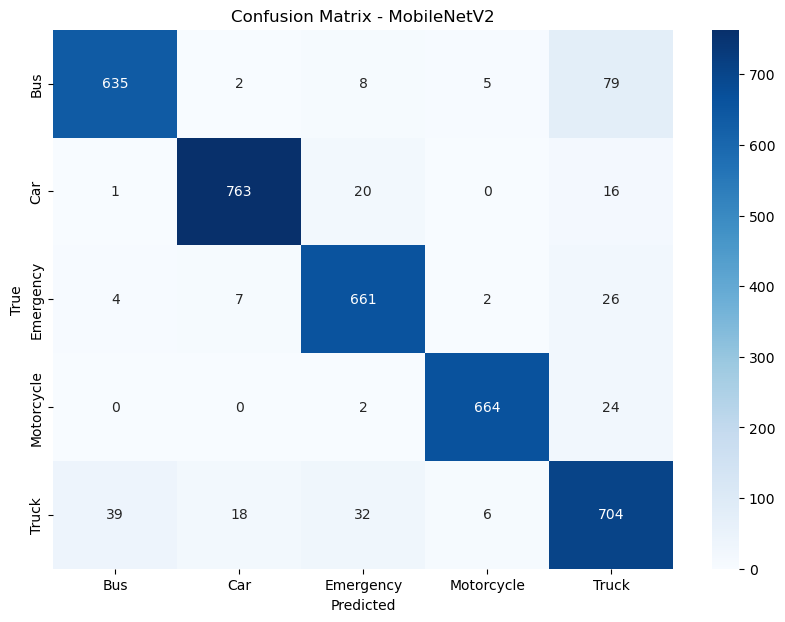

MobileNetV2 - Precision: 0.9251, Recall: 0.9225, F1-score: 0.9233


In [2]:
# === MobileNetV2: препроцесс + генераторы + модель + запуск ===
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_pp

# Генераторы с корректным препроцессом
train_gen_mnv2, val_gen_mnv2, test_gen_mnv2 = make_generators_with_preprocess(mnv2_pp)

# Бэкбон и модель
base_mnv2  = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
model_mnv2 = create_model(base_mnv2, NUM_CLASSES)

# Обучение + оценка
metrics_mnv2, y_true_mnv2, y_pred_cls_mnv2 = train_and_eval(
    model_mnv2, train_gen_mnv2, val_gen_mnv2, test_gen_mnv2, epochs=EPOCHS, title='MobileNetV2')

In [3]:
# === MobileNetV2: сохранение модели/весов/метрик ===
model_path_mnv2   = os.path.join(SAVE_DIR, 'mobilenetv2_finetuned.keras')
weights_path_mnv2 = os.path.join(SAVE_DIR, 'mobilenetv2_weights.weights.h5')
metrics_path_mnv2 = os.path.join(SAVE_DIR, 'mobilenetv2_metrics.npz')

model_mnv2.save(model_path_mnv2)
model_mnv2.save_weights(weights_path_mnv2)

np.savez(metrics_path_mnv2,
         precision=metrics_mnv2['precision'],
         recall=metrics_mnv2['recall'],
         f1=metrics_mnv2['f1'],
         y_true=y_true_mnv2,
         y_pred=y_pred_cls_mnv2)

print("Сохранено:")
print("-", model_path_mnv2)
print("-", weights_path_mnv2)
print("-", metrics_path_mnv2)

Сохранено:
- .\mobilenetv2_finetuned.keras
- .\mobilenetv2_weights.weights.h5
- .\mobilenetv2_metrics.npz


Found 29493 images belonging to 5 classes.
Found 3722 images belonging to 5 classes.
Found 3718 images belonging to 5 classes.


C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1246s 1s/step - accuracy: 0.8349 - loss: 0.6212 - val_accuracy: 0.9111 - val_loss: 0.4716
Epoch 2/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1234s 1s/step - accuracy: 0.9092 - loss: 0.4613 - val_accuracy: 0.9100 - val_loss: 0.4568
Epoch 3/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1237s 1s/step - accuracy: 0.9243 - loss: 0.4261 - val_accuracy: 0.9191 - val_loss: 0.4317
Epoch 4/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1237s 1s/step - accuracy: 0.9347 - loss: 0.4026 - val_accuracy: 0.9113 - val_loss: 0.4400
Epoch 5/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1235s 1s/step - accuracy: 0.9428 - loss: 0.3852 - val_accuracy: 0.9178 - val_loss: 0.4307
Epoch 6/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1236s 1s/step - accuracy: 0.9478 - loss: 0.3724 - val_accuracy: 0.9224 - val_loss: 0.4198
Epoch 7/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1229s 1s/step - accuracy: 0.9536 - loss: 0.3602 - val_accuracy: 0.9205 - val_loss: 0.4323
Epoch 8/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1236s 1s/step - accuracy: 0.9617 - loss: 0.3459 - 

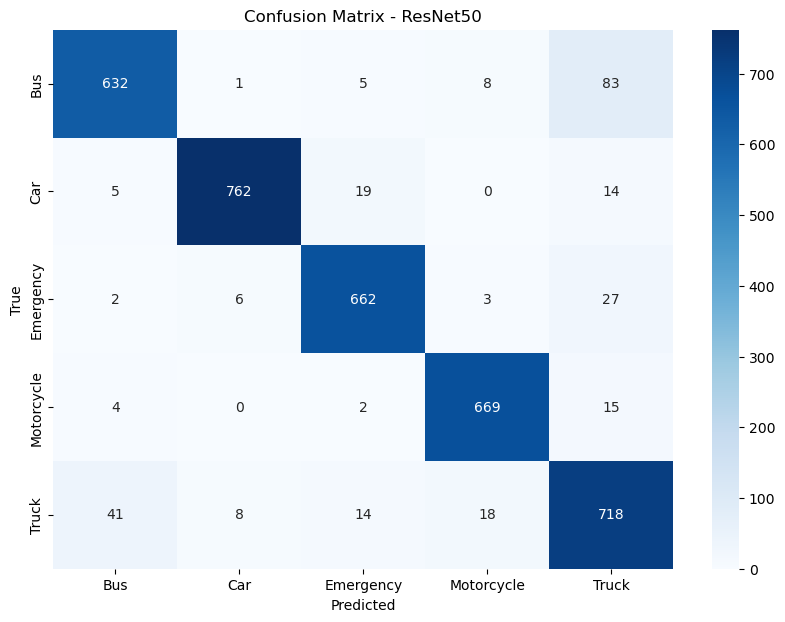

ResNet50 - Precision: 0.9288, Recall: 0.9267, F1-score: 0.9273


In [4]:
# === ResNet50: препроцесс + генераторы + модель + запуск ===
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as rn50_pp

# Генераторы с корректным препроцессом
train_gen_rn50, val_gen_rn50, test_gen_rn50 = make_generators_with_preprocess(rn50_pp)

# Бэкбон и модель (учим только "голову")
base_rn50  = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
model_rn50 = create_model(base_rn50, NUM_CLASSES)

# Обучение + оценка
metrics_rn50, y_true_rn50, y_pred_cls_rn50 = train_and_eval(
    model_rn50, train_gen_rn50, val_gen_rn50, test_gen_rn50, epochs=EPOCHS, title='ResNet50'
)


In [5]:
# === ResNet50: сохранение модели/весов/метрик ===
import os, numpy as np
model_path_rn50   = os.path.join(SAVE_DIR, 'resnet50_finetuned.keras')
weights_path_rn50 = os.path.join(SAVE_DIR, 'resnet50_weights.weights.h5')
metrics_path_rn50 = os.path.join(SAVE_DIR, 'resnet50_metrics.npz')

model_rn50.save(model_path_rn50)
model_rn50.save_weights(weights_path_rn50)

np.savez(metrics_path_rn50,
         precision=metrics_rn50['precision'],
         recall=metrics_rn50['recall'],
         f1=metrics_rn50['f1'],
         y_true=y_true_rn50,
         y_pred=y_pred_cls_rn50)

print("Сохранено:")
print("-", model_path_rn50)
print("-", weights_path_rn50)
print("-", metrics_path_rn50)


Сохранено:
- .\resnet50_finetuned.keras
- .\resnet50_weights.weights.h5
- .\resnet50_metrics.npz


Found 29493 images belonging to 5 classes.
Found 3722 images belonging to 5 classes.
Found 3718 images belonging to 5 classes.


C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 836s 897ms/step - accuracy: 0.8595 - loss: 0.5890 - val_accuracy: 0.9170 - val_loss: 0.4194
Epoch 2/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 786s 853ms/step - accuracy: 0.9280 - loss: 0.4162 - val_accuracy: 0.9232 - val_loss: 0.4087
Epoch 3/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 782s 848ms/step - accuracy: 0.9344 - loss: 0.3984 - val_accuracy: 0.9275 - val_loss: 0.4001
Epoch 4/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 785s 852ms/step - accuracy: 0.9401 - loss: 0.3847 - val_accuracy: 0.9296 - val_loss: 0.3926
Epoch 5/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 782s 848ms/step - accuracy: 0.9458 - loss: 0.3705 - val_accuracy: 0.9261 - val_loss: 0.3942
Epoch 6/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 785s 851ms/step - accuracy: 0.9479 - loss: 0.3652 - val_accuracy: 0.9307 - val_loss: 0.3898
Epoch 7/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 782s 848ms/step - accuracy: 0.9580 - loss: 0.3501 - val_accuracy: 0.9312 - val_loss: 0.3892
Epoch 8/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 784s 850ms/step - accuracy: 0.9563 -

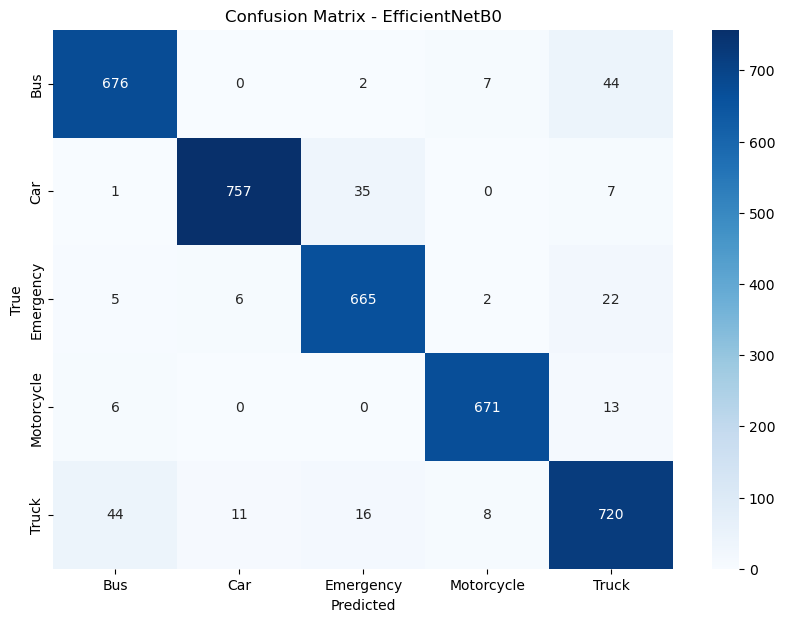

EfficientNetB0 - Precision: 0.9393, Recall: 0.9394, F1-score: 0.9393


In [2]:
# === EfficientNetB0: препроцесс + генераторы + модель + запуск ===
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pp

# Генераторы
train_gen_eff, val_gen_eff, test_gen_eff = make_generators_with_preprocess(eff_pp)

# Бэкбон и модель
base_eff  = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
model_eff = create_model(base_eff, NUM_CLASSES)

# Обучение + оценка
metrics_eff, y_true_eff, y_pred_cls_eff = train_and_eval(
    model_eff, train_gen_eff, val_gen_eff, test_gen_eff, epochs=EPOCHS, title='EfficientNetB0'
)

In [3]:
# === EfficientNetB0: сохранение модели/весов/метрик ===
model_path_eff   = os.path.join(SAVE_DIR, 'efficientnetb0_finetuned.keras')
weights_path_eff = os.path.join(SAVE_DIR, 'efficientnetb0_weights.weights.h5')
metrics_path_eff = os.path.join(SAVE_DIR, 'efficientnetb0_metrics.npz')

model_eff.save(model_path_eff)
model_eff.save_weights(weights_path_eff)

np.savez(metrics_path_eff,
         precision=metrics_eff['precision'],
         recall=metrics_eff['recall'],
         f1=metrics_eff['f1'],
         y_true=y_true_eff,
         y_pred=y_pred_cls_eff)

print("Сохранено:")
print("-", model_path_eff)
print("-", weights_path_eff)
print("-", metrics_path_eff)

Сохранено:
- .\efficientnetb0_finetuned.keras
- .\efficientnetb0_weights.weights.h5
- .\efficientnetb0_metrics.npz


In [2]:
# === ConvNeXtTiny: препроцесс + генераторы + модель + запуск ===
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input as convnext_pp

# Создание генераторов данных с функцией предобработки для ConvNeXtTiny
# convnext_pp нормализует пиксели в соответствии с требованиями ConvNeXtTiny
train_gen_cvt, val_gen_cvt, test_gen_cvt = make_generators_with_preprocess(convnext_pp)

# Инициализация базовой модели ConvNeXtTiny с весами ImageNet
base_cvt = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))

# Создание полной модели с новым классификатором поверх замороженного бэкбона
model_cvt = create_model(base_cvt, NUM_CLASSES)

# Обучение модели и оценка на тестовых данных
# Возвращает метрики (precision, recall, f1), истинные метки и предсказанные классы
metrics_cvt, y_true_cvt, y_pred_cls_cvt = train_and_eval(
    model_cvt, train_gen_cvt, val_gen_cvt, test_gen_cvt, epochs=EPOCHS, title='ConvNeXtTiny')

Found 29493 images belonging to 5 classes.
Found 3722 images belonging to 5 classes.
Found 3718 images belonging to 5 classes.



C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 11/922 ━━━━━━━━━━━━━━━━━━━━ 1:48:13 7s/step - accuracy: 0.2359 - loss: 1.6167 


KeyboardInterrupt



Epoch 1/10
Skipping unsupported file: open-images-dataset\train\Emergency\569337.webpstep - accuracy: 0.4297 - loss: 1.4324
Error loading image: open-images-dataset\train\Emergency\7042hjm75tv9int86ushki0mibk93159.jpg4558 - loss: 1.3889
Skipping unsupported file: open-images-dataset\train\Motorcycle\054f456f9510cca8.jpg.7dbf4a594669 - loss: 1.3697
Skipping unsupported file: open-images-dataset\train\Emergency\569337_aug.webp - accuracy: 0.4692 - loss: 1.3656
Skipping unsupported file: open-images-dataset\train\Motorcycle\0545fc6491989ffd.jpg.fAaB185673 - loss: 1.2752  
Skipping unsupported file: open-images-dataset\train\Emergency\Новые-машины-скорой_aug.webp5187 - loss: 1.2725
Skipping unsupported file: open-images-dataset\train\Motorcycle\054d99529e73772c.jpg.eECBae6c44 - loss: 1.2225
Skipping unsupported file: open-images-dataset\train\Emergency\1679401334-bez-imeni-1_aug.webp7 - loss: 1.2063
Skipping unsupported file: open-images-dataset\train\Emergency\Новые-машины-скорой.webp: 0.

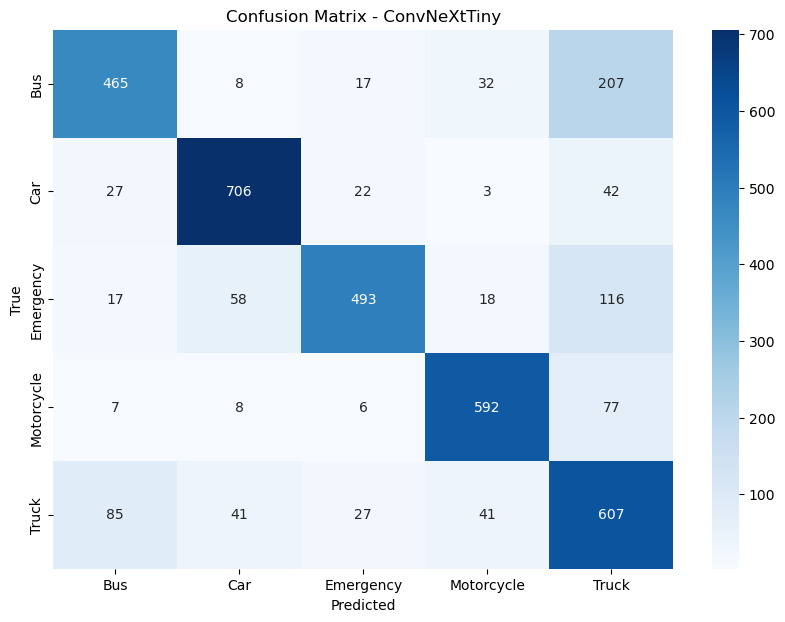

ConvNeXtTiny - Precision: 0.7896, Recall: 0.7677, F1-score: 0.7730


In [10]:
import os
import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input as convnext_pp

# Пользовательская реализация Sequence, совместимая с утилитами обучения
class CustomSequence(Sequence):
    def __init__(self, paths, labels, class_to_idx, batch_size=BATCH_SIZE, img_size=IMG_SIZE, preprocess_fn=None, shuffle=False):
        # Сохранение параметров инициализации
        self.paths = np.array(paths)  # пути к файлам изображений
        self.labels = np.array(labels, dtype=np.int32)  # числовые метки классов
        self.class_indices = class_to_idx  # словарь соответствия имен классов индексам
        self.samples = len(self.paths)  # общее количество образцов
        self.classes = self.labels.copy()  # копия меток для совместимости с ImageDataGenerator
        self.batch_size = batch_size  # размер батча
        self.img_size = img_size  # целевой размер изображений
        self.preprocess_fn = preprocess_fn  # функция предобработки изображений
        self.shuffle = shuffle  # флаг перемешивания данных после каждой эпохи
        self.on_epoch_end()  # инициализация перемешивания если необходимо

    def __len__(self):
        # Возвращает количество батчей в эпохе
        return int(np.ceil(self.samples / float(self.batch_size)))

    def __getitem__(self, idx):
        # Возвращает батч изображений и соответствующие one-hot метки
        start = idx * self.batch_size  # начальный индекс батча
        end = min(start + self.batch_size, self.samples)  # конечный индекс батча
        batch_paths = self.paths[start:end]  # пути для текущего батча
        batch_labels = self.labels[start:end]  # метки для текущего батча

        # Загрузка и предобработка изображений батча
        batch_images = [self._load_image(p) for p in batch_paths]
        batch_images = np.stack(batch_images, axis=0)  # объединение в тензор батча
        # Преобразование меток в one-hot формат
        batch_labels_oh = tf.keras.utils.to_categorical(batch_labels, num_classes=NUM_CLASSES)
        return batch_images, batch_labels_oh

    def on_epoch_end(self):
        # Перемешивание данных в конце каждой эпохи если включено
        if self.shuffle:
            perm = np.random.permutation(self.samples)  # случайная перестановка индексов
            self.paths = self.paths[perm]  # применение перестановки к путям
            self.labels = self.labels[perm]  # применение перестановки к меткам
            self.classes = self.labels.copy()  # обновление копии меток

    def _load_image(self, path):
        # Загрузка и предобработка одного изображения
        # Проверка расширения файла для фильтрации неподдерживаемых форматов
        file_ext = os.path.splitext(path)[1].lower()
        if file_ext not in ['.jpg', '.jpeg', '.png', '.bmp', '.gif']:
            print(f"Skipping unsupported file: {path}")
            return np.zeros(self.img_size + (3,), dtype=np.float32)  # возврат пустого изображения для пропущенных файлов

        try:
            # Чтение и декодирование изображения
            img_bytes = tf.io.read_file(path)
            img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
            img = tf.image.convert_image_dtype(img, tf.float32)  # преобразование в диапазон [0, 1]
            img = tf.image.resize(img, self.img_size)  # изменение размера до целевого

            # Применение пользовательской функции предобработки если задана
            if self.preprocess_fn is not None:
                img = self.preprocess_fn(img)
            return img  # возврат тензора без вызова .numpy() для совместимости

        except tf.errors.InvalidArgumentError:
            # Обработка ошибок загрузки изображений
            print(f"Error loading image: {path}")
            return np.zeros(self.img_size + (3,), dtype=np.float32)  # возврат пустого изображения при ошибке

# Вспомогательная функция для сбора путей к файлам и соответствующих меток
def collect_paths_and_labels(root_folder):
    # Определение классов из структуры train директории для согласованности
    train_root = os.path.join(DATA_DIR, 'train')
    class_names = sorted([d for d in os.listdir(train_root) if os.path.isdir(os.path.join(train_root, d))])
    class_to_idx = {n: i for i, n in enumerate(class_names)}  # создание словаря имя_класса -> индекс

    # Поиск всех изображений в поддиректориях
    pattern = os.path.join(root_folder, '*', '*')
    paths = sorted(glob.glob(pattern))
    if len(paths) == 0:
        raise RuntimeError(f"No images found with pattern: {pattern}")
    
    # Извлечение меток из структуры директорий (имя родительской папки = класс)
    labels = [class_to_idx[os.path.basename(os.path.dirname(p))] for p in paths]
    return paths, labels, class_to_idx

# Сбор данных для train, validation и test наборов
train_paths, train_labels, class_to_idx = collect_paths_and_labels(os.path.join(DATA_DIR, 'train'))
val_paths, val_labels, _ = collect_paths_and_labels(os.path.join(DATA_DIR, 'val'))
test_paths, test_labels, _ = collect_paths_and_labels(os.path.join(DATA_DIR, 'test'))

# Создание генераторов данных для каждой выборки
train_gen_cvt = CustomSequence(train_paths, train_labels, class_to_idx, batch_size=BATCH_SIZE, img_size=IMG_SIZE, preprocess_fn=convnext_pp, shuffle=True)
val_gen_cvt = CustomSequence(val_paths, val_labels, class_to_idx, batch_size=BATCH_SIZE, img_size=IMG_SIZE, preprocess_fn=convnext_pp, shuffle=False)
test_gen_cvt = CustomSequence(test_paths, test_labels, class_to_idx, batch_size=BATCH_SIZE, img_size=IMG_SIZE, preprocess_fn=convnext_pp, shuffle=False)

# Инициализация базовой модели ConvNeXtTiny и создание полной модели
base_cvt = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
model_cvt = create_model(base_cvt, NUM_CLASSES)

# Обучение и оценка модели
metrics_cvt, y_true_cvt, y_pred_cls_cvt = train_and_eval(
    model_cvt, train_gen_cvt, val_gen_cvt, test_gen_cvt, epochs=EPOCHS, title='ConvNeXtTiny'
)

In [11]:
# === ConvNeXtTiny: сохранение модели/весов/метрик ===
import os, numpy as np
model_path_cvt   = os.path.join(SAVE_DIR, 'convnexttiny_finetuned.keras')
weights_path_cvt = os.path.join(SAVE_DIR, 'convnexttiny_weights.weights.h5')
metrics_path_cvt = os.path.join(SAVE_DIR, 'convnexttiny_metrics.npz')

model_cvt.save(model_path_cvt)
model_cvt.save_weights(weights_path_cvt)

np.savez(metrics_path_cvt,
         precision=metrics_cvt['precision'],
         recall=metrics_cvt['recall'],
         f1=metrics_cvt['f1'],
         y_true=y_true_cvt,
         y_pred=y_pred_cls_cvt)

print("Сохранено:")
print("-", model_path_cvt)
print("-", weights_path_cvt)
print("-", metrics_path_cvt)


Сохранено:
- .\convnexttiny_finetuned.keras
- .\convnexttiny_weights.weights.h5
- .\convnexttiny_metrics.npz


Found 29493 images belonging to 5 classes.
Found 3722 images belonging to 5 classes.
Found 3718 images belonging to 5 classes.


C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 839s 904ms/step - accuracy: 0.2714 - loss: 1.5437 - val_accuracy: 0.3452 - val_loss: 1.4215
Epoch 2/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 778s 843ms/step - accuracy: 0.3860 - loss: 1.3961 - val_accuracy: 0.4670 - val_loss: 1.3030
Epoch 3/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 827s 897ms/step - accuracy: 0.4742 - loss: 1.2738 - val_accuracy: 0.5419 - val_loss: 1.1785
Epoch 4/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1091s 1s/step - accuracy: 0.5453 - loss: 1.1702 - val_accuracy: 0.6085 - val_loss: 1.0702
Epoch 5/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 939s 1s/step - accuracy: 0.6064 - loss: 1.0749 - val_accuracy: 0.6451 - val_loss: 0.9964
Epoch 6/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1060s 1s/step - accuracy: 0.6487 - loss: 0.9921 - val_accuracy: 0.6252 - val_loss: 0.9922
Epoch 7/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1062s 1s/step - accuracy: 0.6689 - loss: 0.9505 - val_accuracy: 0.6897 - val_loss: 0.9022
Epoch 8/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 896s 971ms/step - accuracy: 0.6835 - loss: 0.

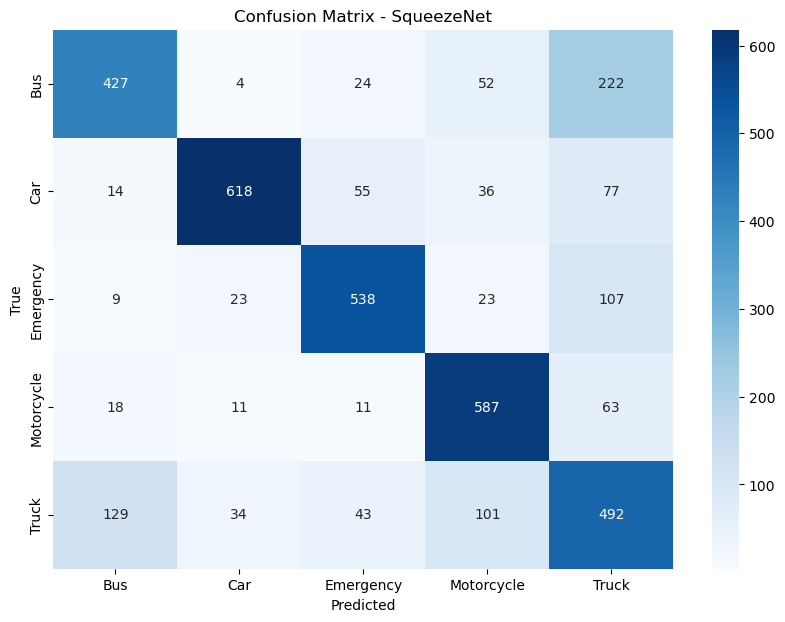

SqueezeNet - Precision: 0.7319, Recall: 0.7187, F1-score: 0.7212


In [2]:
# === SqueezeNet: препроцесс (rescale) + модель + запуск ===
# Импортируем необходимые модули TensorFlow для построения архитектуры SqueezeNet
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, concatenate, Activation
from tensorflow.keras.models import Model

# Создаем генераторы данных с обычным масштабированием (обучение с нуля без предобученных весов)
train_gen_sqz, val_gen_sqz, test_gen_sqz = make_generators_with_preprocess(preprocess_fn=None)

def fire_module(x, squeeze_filters, expand_filters):
    """
    Fire module - ключевой строительный блок архитектуры SqueezeNet.
    Состоит из squeeze слоя (свертка 1x1) и expand слоев (свертки 1x1 и 3x3).
    """
    # Squeeze слой: уменьшает количество каналов
    x = Conv2D(squeeze_filters,(1,1),padding='same',activation='relu')(x)
    # Expand слои: два параллельных пути сверток
    l = Conv2D(expand_filters,(1,1),padding='same',activation='relu')(x)
    r = Conv2D(expand_filters,(3,3),padding='same',activation='relu')(x)
    # Объединение результатов по каналам
    return concatenate([l, r], axis=-1)

def build_squeezenet(input_shape=(*IMG_SIZE,3), num_classes=NUM_CLASSES):
    """
    Строит архитектуру SqueezeNet с нуля.
    Включает начальный сверточный слой, последовательность fire модулей
    и классификационную голову.
    """
    # Входной слой
    inp = Input(shape=input_shape)
    
    # Начальный сверточный слой
    x = Conv2D(96,(7,7),strides=(2,2),padding='same',activation='relu')(inp)
    x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x)

    # Блоки fire модулей с промежуточными пулингами
    x = fire_module(x,16,64); x = fire_module(x,16,64); x = fire_module(x,32,128)
    x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x)

    x = fire_module(x,32,128); x = fire_module(x,48,192); x = fire_module(x,48,192)
    x = fire_module(x,64,256)
    x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x)

    # Финальный fire модуль и классификатор
    x = fire_module(x,64,256)
    x = Dropout(0.5)(x)  # Регуляризация для предотвращения переобучения
    x = Conv2D(num_classes,(1,1),padding='same')(x)
    x = GlobalAveragePooling2D()(x)  # Замена полносвязных слоев для уменьшения параметров
    out = Activation('softmax')(x)    # Выходной слой с вероятностями классов
    
    return Model(inp, out)

# Создание экземпляра модели SqueezeNet
model_sqz = build_squeezenet()

# Для SqueezeNet не используем create_model (так как это уже полная модель с классификатором)
model_sqz.compile(optimizer=Adam(LR_HEAD),
                  loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
                  metrics=['accuracy'])

# Обучение модели и оценка на тестовых данных
metrics_sqz, y_true_sqz, y_pred_cls_sqz = train_and_eval(
    model_sqz, train_gen_sqz, val_gen_sqz, test_gen_sqz, epochs=EPOCHS, title='SqueezeNet'
)

In [3]:
# === SqueezeNet: сохранение модели/весов/метрик ===
import os, numpy as np
model_path_sqz   = os.path.join(SAVE_DIR, 'squeezenet_finetuned.keras')
weights_path_sqz = os.path.join(SAVE_DIR, 'squeezenet_weights.weights.h5')
metrics_path_sqz = os.path.join(SAVE_DIR, 'squeezenet_metrics.npz')

model_sqz.save(model_path_sqz)
model_sqz.save_weights(weights_path_sqz)

np.savez(metrics_path_sqz,
         precision=metrics_sqz['precision'],
         recall=metrics_sqz['recall'],
         f1=metrics_sqz['f1'],
         y_true=y_true_sqz,
         y_pred=y_pred_cls_sqz)

print("Сохранено:")
print("-", model_path_sqz)
print("-", weights_path_sqz)
print("-", metrics_path_sqz)

Сохранено:
- .\squeezenet_finetuned.keras
- .\squeezenet_weights.weights.h5
- .\squeezenet_metrics.npz



--- Evaluating MobileNetV2 (mobilenetv2_finetuned.keras) ---
Found 3718 images belonging to 5 classes.


C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


MobileNetV2 -> Acc: 0.9217, Prec: 0.9251, Rec: 0.9225, F1: 0.9233

--- Evaluating ResNet50 (resnet50_finetuned.keras) ---
Found 3718 images belonging to 5 classes.


C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


ResNet50 -> Acc: 0.9260, Prec: 0.9288, Rec: 0.9267, F1: 0.9273

--- Evaluating EfficientNetB0 (efficientnetb0_finetuned.keras) ---
Found 3718 images belonging to 5 classes.


...

EfficientNetB0 -> Acc: 0.9384, Prec: 0.9393, Rec: 0.9394, F1: 0.9393

--- Evaluating ConvNeXtTiny (convnexttiny_finetuned.keras) ---
Found 3718 images belonging to 5 classes.


C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


ConvNeXtTiny -> Acc: 0.8346, Prec: 0.8390, Rec: 0.8359, F1: 0.8365

--- Evaluating SqueezeNet (squeezenet_finetuned.keras) ---
Found 3718 images belonging to 5 classes.


C:\Users\Ana\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


SqueezeNet -> Acc: 0.7160, Prec: 0.7319, Rec: 0.7187, F1: 0.7212


=== Итоговая таблица ===
                accuracy  precision    recall        f1  samples
model                                                           
MobileNetV2     0.921732   0.925055  0.922502  0.923320     3718
ResNet50        0.926036   0.928790  0.926669  0.927287     3718
EfficientNetB0  0.938408   0.939262  0.939428  0.939257     3718
ConvNeXtTiny    0.834588   0.838993  0.835869  0.836534     3718
SqueezeNet      0.715976   0.731864  0.718660  0.721188     3718


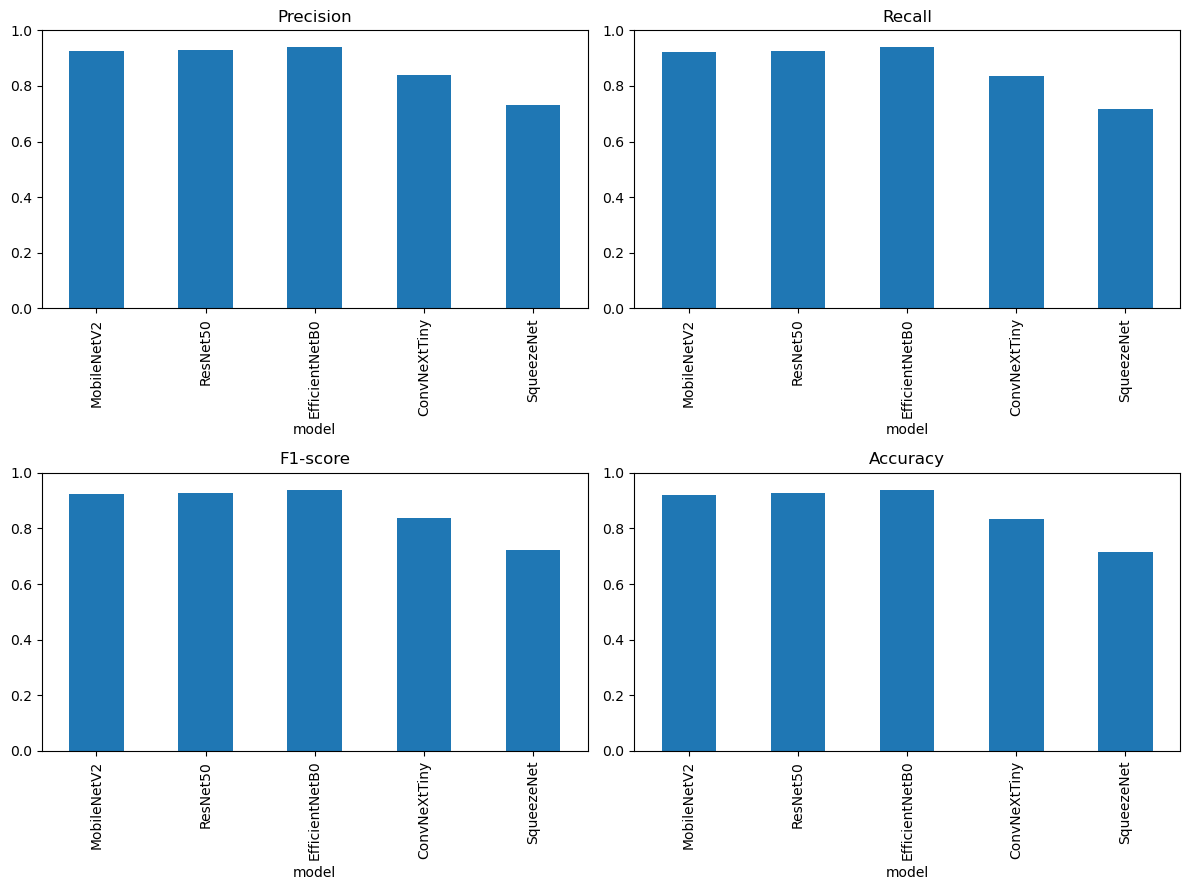

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# paths
TEST_DIR = 'open-images-dataset/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# модели и соответствующие им preprocess функции
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenetv2_pp
from tensorflow.keras.applications.resnet import preprocess_input as resnet_pp
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_pp
# convnext_pp у тебя уже импортирован ранее (если нет — импортируй как в тренировке)
from tensorflow.keras.applications.convnext import preprocess_input as convnext_pp

model_paths = [
    'mobilenetv2_finetuned.keras',
    'resnet50_finetuned.keras',
    'efficientnetb0_finetuned.keras',
    'convnexttiny_finetuned.keras',
    'squeezenet_finetuned.keras'
]
model_names = ['MobileNetV2', 'ResNet50', 'EfficientNetB0', 'ConvNeXtTiny', 'SqueezeNet']

# карта preprocess функций — подстраивается под то, как модель обучалась
preprocess_map = {
    'MobileNetV2': mobilenetv2_pp,          # ожидает 0..255 -> масштабирует в [-1,1]
    'ResNet50': resnet_pp,                  # ожидает 0..255 -> mean-subtraction
    'EfficientNetB0': efficientnet_pp,     # ожидает 0..255
    'ConvNeXtTiny': convnext_pp,           # твой convnext preprocessing
    # Если SqueezeNet обучался просто с rescale=1./255, используем простую нормализацию:
    'SqueezeNet': (lambda x: x / 255.0)
}

# контейнеры для метрик
rows = []

for path, name in zip(model_paths, model_names):
    print(f"\n--- Evaluating {name} ({path}) ---")
    # создаём генератор теста с нужной предобработкой (без дополнительного rescale)
    pp_fn = preprocess_map[name]
    test_datagen = ImageDataGenerator(preprocessing_function=pp_fn)  # не ставим rescale тут
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    # истинные метки (в порядке, в котором flow_from_directory выдал файлы)
    y_true = test_generator.classes

    # загружаем модель
    model = load_model(path)

    # предсказания (Keras корректно использует generator)
    y_pred_proba = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # метрики
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    print(f"{name} -> Acc: {accuracy:.4f}, Prec: {precision:.4f}, Rec: {recall:.4f}, F1: {f1:.4f}")

    rows.append({
        'model': name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'samples': test_generator.samples
    })

# Таблица результатов
df = pd.DataFrame(rows).set_index('model')
print("\n\n=== Итоговая таблица ===")
print(df)

# Визуализация (один общий график с метриками)
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
df['precision'].plot(kind='bar', ax=ax[0,0], title='Precision'); ax[0,0].set_ylim(0,1)
df['recall'].plot(kind='bar', ax=ax[0,1], title='Recall'); ax[0,1].set_ylim(0,1)
df['f1'].plot(kind='bar', ax=ax[1,0], title='F1-score'); ax[1,0].set_ylim(0,1)
df['accuracy'].plot(kind='bar', ax=ax[1,1], title='Accuracy'); ax[1,1].set_ylim(0,1)
plt.tight_layout()
plt.show()
